In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from vcdvcd import VCDVCD

# Project paths
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results" / "activity_analysis"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Discover all VCD files
vcd_files = sorted(DATA_DIR.glob("*.vcd"))

print("Project root :", PROJECT_ROOT)
print("Data dir     :", DATA_DIR)
print("Results dir  :", RESULTS_DIR)
print("VCD files found:", len(vcd_files))

for f in vcd_files:
    print("-", f.name)

Project root : /home/aditya_chaudhry/thermal_aware_mac
Data dir     : /home/aditya_chaudhry/thermal_aware_mac/data
Results dir  : /home/aditya_chaudhry/thermal_aware_mac/results/activity_analysis
VCD files found: 24
- mac_array_checkerboard_16x16.vcd
- mac_array_checkerboard_2x2.vcd
- mac_array_checkerboard_4x4.vcd
- mac_array_checkerboard_8x8.vcd
- mac_array_hotspot_16x16.vcd
- mac_array_hotspot_2x2.vcd
- mac_array_hotspot_4x4.vcd
- mac_array_hotspot_8x8.vcd
- mac_array_uniform_16x16.vcd
- mac_array_uniform_2x2.vcd
- mac_array_uniform_4x4.vcd
- mac_array_uniform_8x8.vcd
- systolic_mac_array_checkerboard_16x16.vcd
- systolic_mac_array_checkerboard_2x2.vcd
- systolic_mac_array_checkerboard_4x4.vcd
- systolic_mac_array_checkerboard_8x8.vcd
- systolic_mac_array_hotspot_16x16.vcd
- systolic_mac_array_hotspot_2x2.vcd
- systolic_mac_array_hotspot_4x4.vcd
- systolic_mac_array_hotspot_8x8.vcd
- systolic_mac_array_uniform_16x16.vcd
- systolic_mac_array_uniform_2x2.vcd
- systolic_mac_array_unifo

In [2]:
import re

def parse_vcd_filename(path: Path):
    """
    Parse filenames like:
      mac_array_uniform_8x8.vcd
      systolic_mac_array_hotspot_16x16.vcd
    """
    name = path.stem  # remove .vcd

    standard_pat = r"^(mac_array)_(uniform|hotspot|checkerboard)_(\d+)x(\d+)$"
    systolic_pat = r"^(systolic_mac_array)_(uniform|hotspot|checkerboard)_(\d+)x(\d+)$"

    m_std = re.match(standard_pat, name)
    m_sys = re.match(systolic_pat, name)

    if m_std:
        arch_raw, workload, n1, n2 = m_std.groups()
        architecture = "standard"
    elif m_sys:
        arch_raw, workload, n1, n2 = m_sys.groups()
        architecture = "systolic"
    else:
        raise ValueError(f"Unrecognized VCD filename format: {path.name}")

    n1 = int(n1)
    n2 = int(n2)

    if n1 != n2:
        raise ValueError(f"Non-square array size found in filename: {path.name}")

    return {
        "filename": path.name,
        "filepath": str(path),
        "architecture": architecture,
        "workload": workload,
        "N": n1,
        "shape": f"{n1}x{n2}",
    }

file_records = [parse_vcd_filename(p) for p in vcd_files]
files_df = pd.DataFrame(file_records).sort_values(
    by=["architecture", "N", "workload"]
).reset_index(drop=True)

print("Parsed file metadata:")
display(files_df)

print("\nCounts by architecture:")
display(files_df["architecture"].value_counts())

print("\nCounts by workload:")
display(files_df["workload"].value_counts())

print("\nCounts by size:")
display(files_df["shape"].value_counts().sort_index())

Parsed file metadata:


,filename,filepath,architecture,workload,N,shape
0,mac_array_checkerboard_2x2.vcd,/home/aditya_chaudhry/thermal_aware_mac/data/m...,standard,checkerboard,2,2x2
1,mac_array_hotspot_2x2.vcd,/home/aditya_chaudhry/thermal_aware_mac/data/m...,standard,hotspot,2,2x2
2,mac_array_uniform_2x2.vcd,/home/aditya_chaudhry/thermal_aware_mac/data/m...,standard,uniform,2,2x2
3,mac_array_checkerboard_4x4.vcd,/home/aditya_chaudhry/thermal_aware_mac/data/m...,standard,checkerboard,4,4x4
4,mac_array_hotspot_4x4.vcd,/home/aditya_chaudhry/thermal_aware_mac/data/m...,standard,hotspot,4,4x4
5,mac_array_uniform_4x4.vcd,/home/aditya_chaudhry/thermal_aware_mac/data/m...,standard,uniform,4,4x4
6,mac_array_checkerboard_8x8.vcd,/home/aditya_chaudhry/thermal_aware_mac/data/m...,standard,checkerboard,8,8x8
7,mac_array_hotspot_8x8.vcd,/home/aditya_chaudhry/thermal_aware_mac/data/m...,standard,hotspot,8,8x8
8,mac_array_uniform_8x8.vcd,/home/aditya_chaudhry/thermal_aware_mac/data/m...,standard,uniform,8,8x8
9,mac_array_checkerboard_16x16.vcd,/home/aditya_chaudhry/thermal_aware_mac/data/m...,standard,checkerboard,16,16x16



Counts by architecture:


architecture
standard    12
systolic    12
Name: count, dtype: int64


Counts by workload:


workload
checkerboard    8
hotspot         8
uniform         8
Name: count, dtype: int64


Counts by size:


shape
16x16    6
2x2      6
4x4      6
8x8      6
Name: count, dtype: int64

In [3]:
# Pick one standard VCD for signal inspection
sample_std_path = files_df[
    (files_df["architecture"] == "standard") &
    (files_df["N"] == 2) &
    (files_df["workload"] == "uniform")
]["filepath"].iloc[0]

print("Inspecting standard VCD:")
print(sample_std_path)

vcd_std = VCDVCD(sample_std_path)

std_signals = list(vcd_std.signals)
print(f"\nTotal signals in standard VCD: {len(std_signals)}")

print("\nFirst 40 signals:")
for sig in std_signals[:40]:
    print(sig)

activity_signals_std = [s for s in std_signals if "activity_count" in s]
acc_signals_std      = [s for s in std_signals if ".acc_out" in s]
mult_signals_std     = [s for s in std_signals if ".mult_out" in s]
workload_signals_std = [s for s in std_signals if "workload_id" in s]

print("\nDetected activity_count signals:")
for s in activity_signals_std[:20]:
    print(s)
print("Total activity_count signals:", len(activity_signals_std))

print("\nDetected acc_out signals:")
for s in acc_signals_std[:20]:
    print(s)
print("Total acc_out signals:", len(acc_signals_std))

print("\nDetected mult_out signals:")
for s in mult_signals_std[:20]:
    print(s)
print("Total mult_out signals:", len(mult_signals_std))

print("\nDetected workload_id signals:")
for s in workload_signals_std:
    print(s)
print("Total workload_id signals:", len(workload_signals_std))

Inspecting standard VCD:
/home/aditya_chaudhry/thermal_aware_mac/data/mac_array_uniform_2x2.vcd

Total signals in standard VCD: 56

First 40 signals:
tb_mac_array.clk
tb_mac_array.rst
tb_mac_array.workload_id[1:0]
tb_mac_array.i[31:0]
tb_mac_array.j[31:0]
tb_mac_array.c[31:0]
tb_mac_array.hot_i[31:0]
tb_mac_array.hot_j[31:0]
tb_mac_array.HOT_N[31:0]
tb_mac_array.dut.clk
tb_mac_array.dut.rst
tb_mac_array.dut.ROW[0].COL[0].u_mac.clk
tb_mac_array.dut.ROW[0].COL[0].u_mac.rst
tb_mac_array.dut.ROW[0].COL[0].u_mac.en
tb_mac_array.dut.ROW[0].COL[0].u_mac.a[31:24]
tb_mac_array.dut.ROW[0].COL[0].u_mac.b[31:24]
tb_mac_array.dut.ROW[0].COL[0].u_mac.acc_out[127:96]
tb_mac_array.dut.ROW[0].COL[0].u_mac.mult_out[63:48]
tb_mac_array.dut.ROW[0].COL[0].u_mac.activity_count[63:48]
tb_mac_array.dut.ROW[0].COL[0].u_mac.mult[15:0]
tb_mac_array.dut.ROW[0].COL[0].u_mac.mult_ext[31:0]
tb_mac_array.dut.ROW[0].COL[0].u_mac.acc_next[31:0]
tb_mac_array.dut.ROW[0].COL[1].u_mac.clk
tb_mac_array.dut.ROW[0].COL[1].u_m

In [4]:
# Pick one systolic VCD for signal inspection
sample_sys_path = files_df[
    (files_df["architecture"] == "systolic") &
    (files_df["N"] == 2) &
    (files_df["workload"] == "uniform")
]["filepath"].iloc[0]

print("Inspecting systolic VCD:")
print(sample_sys_path)

vcd_sys = VCDVCD(sample_sys_path)

sys_signals = list(vcd_sys.signals)
print(f"\nTotal signals in systolic VCD: {len(sys_signals)}")

print("\nFirst 50 signals:")
for sig in sys_signals[:50]:
    print(sig)

activity_signals_sys = [s for s in sys_signals if "activity_count" in s]
acc_signals_sys      = [s for s in sys_signals if ".acc_out" in s]
mult_signals_sys     = [s for s in sys_signals if ".mult_out" in s]
a_out_signals_sys    = [s for s in sys_signals if ".a_out" in s]
b_out_signals_sys    = [s for s in sys_signals if ".b_out" in s]
workload_signals_sys = [s for s in sys_signals if "workload_id" in s]

print("\nDetected activity_count signals:")
for s in activity_signals_sys[:20]:
    print(s)
print("Total activity_count signals:", len(activity_signals_sys))

print("\nDetected acc_out signals:")
for s in acc_signals_sys[:20]:
    print(s)
print("Total acc_out signals:", len(acc_signals_sys))

print("\nDetected mult_out signals:")
for s in mult_signals_sys[:20]:
    print(s)
print("Total mult_out signals:", len(mult_signals_sys))

print("\nDetected a_out signals:")
for s in a_out_signals_sys[:20]:
    print(s)
print("Total a_out signals:", len(a_out_signals_sys))

print("\nDetected b_out signals:")
for s in b_out_signals_sys[:20]:
    print(s)
print("Total b_out signals:", len(b_out_signals_sys))

print("\nDetected workload_id signals:")
for s in workload_signals_sys:
    print(s)
print("Total workload_id signals:", len(workload_signals_sys))

Inspecting systolic VCD:
/home/aditya_chaudhry/thermal_aware_mac/data/systolic_mac_array_uniform_2x2.vcd

Total signals in systolic VCD: 73

First 50 signals:
tb_systolic_mac_array.clk
tb_systolic_mac_array.rst
tb_systolic_mac_array.en
tb_systolic_mac_array.workload_id[1:0]
tb_systolic_mac_array.i[31:0]
tb_systolic_mac_array.c[31:0]
tb_systolic_mac_array.HOT_N[31:0]
tb_systolic_mac_array.dut.clk
tb_systolic_mac_array.dut.rst
tb_systolic_mac_array.dut.en
tb_systolic_mac_array.dut.\ROW[0].COL[0].a_in_cell[7:0]
tb_systolic_mac_array.dut.\ROW[0].COL[0].b_in_cell[7:0]
tb_systolic_mac_array.dut.\ROW[0].COL[1].a_in_cell[7:0]
tb_systolic_mac_array.dut.\ROW[0].COL[1].b_in_cell[7:0]
tb_systolic_mac_array.dut.\ROW[1].COL[0].a_in_cell[7:0]
tb_systolic_mac_array.dut.\ROW[1].COL[0].b_in_cell[7:0]
tb_systolic_mac_array.dut.\ROW[1].COL[1].a_in_cell[7:0]
tb_systolic_mac_array.dut.\ROW[1].COL[1].b_in_cell[7:0]
tb_systolic_mac_array.dut.ROW[0].COL[0].u_cell.clk
tb_systolic_mac_array.dut.ROW[0].COL[0].u_c

In [5]:
ROW_COL_PATTERN = re.compile(r"ROW\[(\d+)\]\.COL\[(\d+)\]")

def build_activity_signal_map(signal_names):
    """
    Build {(row, col): signal_name} for per-cell activity_count signals.
    Works for both standard and systolic VCD naming styles.
    """
    signal_map = {}

    for sig in signal_names:
        # Keep only true per-cell activity_count signals
        if "activity_count" not in sig:
            continue
        if "ROW[" not in sig or "COL[" not in sig:
            continue

        m = ROW_COL_PATTERN.search(sig)
        if not m:
            continue

        row = int(m.group(1))
        col = int(m.group(2))
        signal_map[(row, col)] = sig

    return signal_map

# Test on standard sample
std_activity_map = build_activity_signal_map(std_signals)
print("Standard activity signal map:")
for k in sorted(std_activity_map):
    print(k, "->", std_activity_map[k])

# Test on systolic sample
sys_activity_map = build_activity_signal_map(sys_signals)
print("\nSystolic activity signal map:")
for k in sorted(sys_activity_map):
    print(k, "->", sys_activity_map[k])

print("\nStandard map size:", len(std_activity_map))
print("Systolic map size:", len(sys_activity_map))

Standard activity signal map:
(0, 0) -> tb_mac_array.dut.ROW[0].COL[0].u_mac.activity_count[63:48]
(0, 1) -> tb_mac_array.dut.ROW[0].COL[1].u_mac.activity_count[47:32]
(1, 0) -> tb_mac_array.dut.ROW[1].COL[0].u_mac.activity_count[31:16]
(1, 1) -> tb_mac_array.dut.ROW[1].COL[1].u_mac.activity_count[15:0]

Systolic activity signal map:
(0, 0) -> tb_systolic_mac_array.dut.ROW[0].COL[0].u_cell.activity_count[63:48]
(0, 1) -> tb_systolic_mac_array.dut.ROW[0].COL[1].u_cell.activity_count[47:32]
(1, 0) -> tb_systolic_mac_array.dut.ROW[1].COL[0].u_cell.activity_count[31:16]
(1, 1) -> tb_systolic_mac_array.dut.ROW[1].COL[1].u_cell.activity_count[15:0]

Standard map size: 4
Systolic map size: 4


In [12]:
def binary_to_int_safe(v):
    """
    Convert a VCD scalar/vector value to int safely.
    Treats plain VCD values as binary by default.
    Returns None for values containing x/z.
    """
    if v is None:
        return None

    v = str(v).strip().lower()

    if any(ch in v for ch in ["x", "z"]):
        return None

    # Handle explicit base prefixes if they ever appear
    if v.startswith("0b"):
        return int(v, 2)
    if v.startswith("0x"):
        return int(v, 16)
    if v.startswith("0d"):
        return int(v[2:], 10)

    # Default: VCD vector values are binary strings
    return int(v, 2)


def get_last_valid_value(tv):
    """
    Return the last valid non-x/non-z value from a VCD time-value list.
    """
    for t, v in reversed(tv):
        val_int = binary_to_int_safe(v)
        if val_int is not None:
            return t, val_int, v
    return None, None, None


def extract_final_activity_matrix(vcd_obj, signal_map, N, verbose=False):
    """
    Extract final valid activity_count value for each cell and return NxN matrix.
    Uses the last non-x/non-z value in the signal history.
    """
    mat = np.zeros((N, N), dtype=np.int32)

    for (row, col), sig in signal_map.items():
        tv = vcd_obj[sig].tv
        if len(tv) == 0:
            raise ValueError(f"No time-value data found for signal: {sig}")

        last_t, val_int, raw_val = get_last_valid_value(tv)

        if val_int is None:
            raise ValueError(f"No valid non-x/non-z value found for signal: {sig}")

        if verbose:
            print(f"({row}, {col}) -> time={last_t}, raw_binary='{raw_val}', decimal={val_int}")

        mat[row, col] = val_int

    return mat


std_activity_matrix = extract_final_activity_matrix(vcd_std, std_activity_map, N=2, verbose=True)
print("\nStandard activity matrix:")
print(std_activity_matrix)

sys_activity_matrix = extract_final_activity_matrix(vcd_sys, sys_activity_map, N=2, verbose=True)
print("\nSystolic activity matrix:")
print(sys_activity_matrix)

(0, 0) -> time=115000, raw_binary='1010', decimal=10
(0, 1) -> time=115000, raw_binary='1010', decimal=10
(1, 0) -> time=115000, raw_binary='1010', decimal=10
(1, 1) -> time=115000, raw_binary='1010', decimal=10

Standard activity matrix:
[[10 10]
 [10 10]]
(0, 0) -> time=145000, raw_binary='1100', decimal=12
(0, 1) -> time=155000, raw_binary='1101', decimal=13
(1, 0) -> time=155000, raw_binary='1101', decimal=13
(1, 1) -> time=155000, raw_binary='1100', decimal=12

Systolic activity matrix:
[[12 13]
 [13 12]]


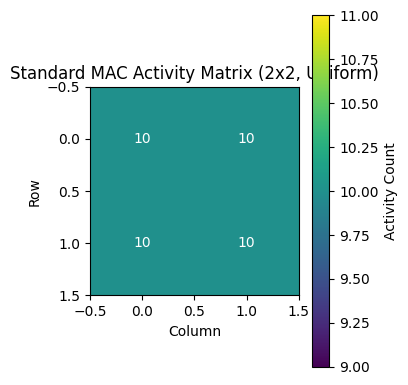

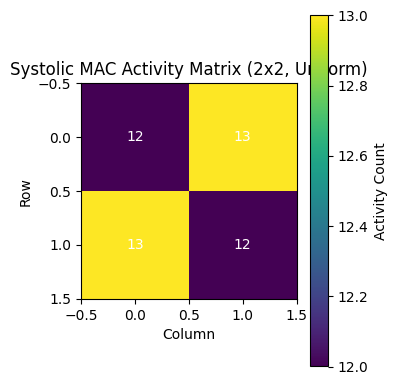

In [13]:
def plot_activity_matrix(mat, title, annotate=True):
    plt.figure(figsize=(4, 4))
    im = plt.imshow(mat, interpolation="nearest")
    plt.colorbar(im, label="Activity Count")
    plt.title(title)
    plt.xlabel("Column")
    plt.ylabel("Row")

    if annotate:
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                plt.text(j, i, f"{mat[i, j]}", ha="center", va="center", color="white", fontsize=10)

    plt.tight_layout()
    plt.show()

plot_activity_matrix(std_activity_matrix, "Standard MAC Activity Matrix (2x2, Uniform)")
plot_activity_matrix(sys_activity_matrix, "Systolic MAC Activity Matrix (2x2, Uniform)")

In [14]:
def process_vcd_file(row, verbose=False):
    filepath = row["filepath"]
    N = int(row["N"])

    if verbose:
        print(f"\nProcessing: {filepath}")

    # Load VCD
    vcd = VCDVCD(filepath)

    # Build signal map
    signal_map = build_activity_signal_map(vcd.signals)

    if len(signal_map) != N * N:
        print(f"WARNING: Expected {N*N} cells, found {len(signal_map)}")

    # Extract matrix
    activity_matrix = extract_final_activity_matrix(vcd, signal_map, N)

    # Compute stats
    summary = {
        "architecture": row["architecture"],
        "workload": row["workload"],
        "N": N,
        "shape": row["shape"],

        "sum_activity": int(np.sum(activity_matrix)),
        "max_activity": int(np.max(activity_matrix)),
        "min_activity": int(np.min(activity_matrix)),
        "mean_activity": float(np.mean(activity_matrix)),
        "std_activity": float(np.std(activity_matrix)),
        "nonzero_cells": int(np.count_nonzero(activity_matrix))
    }

    return activity_matrix, summary


# Test on a few entries
test_rows = files_df.sample(3, random_state=42)

for _, row in test_rows.iterrows():
    mat, summary = process_vcd_file(row, verbose=True)

    print("\nMatrix:")
    print(mat)

    print("\nSummary:")
    for k, v in summary.items():
        print(f"{k}: {v}")

    print("\n" + "="*50)


Processing: /home/aditya_chaudhry/thermal_aware_mac/data/mac_array_uniform_8x8.vcd

Matrix:
[[10 10 10 10 10 10 10 10]
 [10 10 10 10 10 10 10 10]
 [10 10 10 10 10 10 10 10]
 [10 10 10 10 10 10 10 10]
 [10 10 10 10 10 10 10 10]
 [10 10 10 10 10 10 10 10]
 [10 10 10 10 10 10 10 10]
 [10 10 10 10 10 10 10 10]]

Summary:
architecture: standard
workload: uniform
N: 8
shape: 8x8
sum_activity: 640
max_activity: 10
min_activity: 10
mean_activity: 10.0
std_activity: 0.0
nonzero_cells: 64


Processing: /home/aditya_chaudhry/thermal_aware_mac/data/systolic_mac_array_hotspot_4x4.vcd

Matrix:
[[12 13 12 12]
 [13 12 12 12]
 [12 12  0  0]
 [12 12  0  0]]

Summary:
architecture: systolic
workload: hotspot
N: 4
shape: 4x4
sum_activity: 146
max_activity: 13
min_activity: 0
mean_activity: 9.125
std_activity: 5.278198082679353
nonzero_cells: 12


Processing: /home/aditya_chaudhry/thermal_aware_mac/data/mac_array_checkerboard_2x2.vcd

Matrix:
[[10  0]
 [ 0 10]]

Summary:
architecture: standard
workload: c

In [15]:
all_matrices = {}
summary_rows = []

for _, row in files_df.iterrows():
    mat, summary = process_vcd_file(row, verbose=False)

    key = (row["architecture"], row["N"], row["workload"])
    all_matrices[key] = mat
    summary_rows.append(summary)

activity_summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["architecture", "N", "workload"]
).reset_index(drop=True)

print("Processed files:", len(activity_summary_df))
display(activity_summary_df)

Processed files: 24


,architecture,workload,N,shape,sum_activity,max_activity,min_activity,mean_activity,std_activity,nonzero_cells
0,standard,checkerboard,2,2x2,20,10,0,5.000000,5.000000,2
1,standard,hotspot,2,2x2,10,10,0,2.500000,4.330127,1
2,standard,uniform,2,2x2,40,10,10,10.000000,0.000000,4
3,standard,checkerboard,4,4x4,80,10,0,5.000000,5.000000,8
4,standard,hotspot,4,4x4,40,10,0,2.500000,4.330127,4
5,standard,uniform,4,4x4,160,10,10,10.000000,0.000000,16
6,standard,checkerboard,8,8x8,320,10,0,5.000000,5.000000,32
7,standard,hotspot,8,8x8,160,10,0,2.500000,4.330127,16
8,standard,uniform,8,8x8,640,10,10,10.000000,0.000000,64
9,standard,checkerboard,16,16x16,1280,10,0,5.000000,5.000000,128


In [17]:
import json

# Save summary table
summary_csv_path = RESULTS_DIR / "activity_summary.csv"
activity_summary_df.to_csv(summary_csv_path, index=False)

# Save matrices as .npy (dictionary)
matrices_npy_path = RESULTS_DIR / "activity_matrices.npy"
np.save(matrices_npy_path, all_matrices, allow_pickle=True)

print("Saved summary CSV :", summary_csv_path)
print("Saved matrices NPY:", matrices_npy_path)

Saved summary CSV : /home/aditya_chaudhry/thermal_aware_mac/results/activity_analysis/activity_summary.csv
Saved matrices NPY: /home/aditya_chaudhry/thermal_aware_mac/results/activity_analysis/activity_matrices.npy


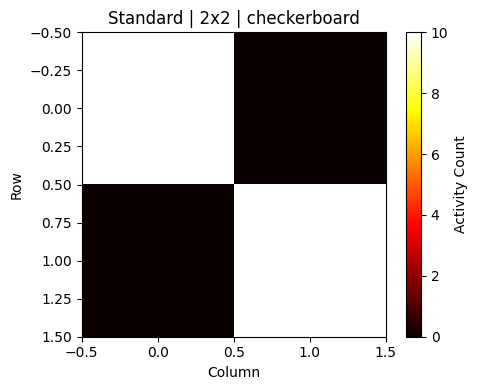

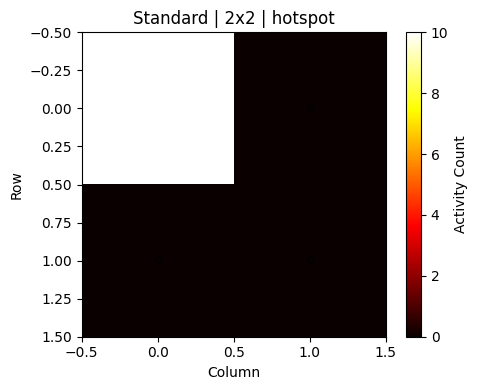

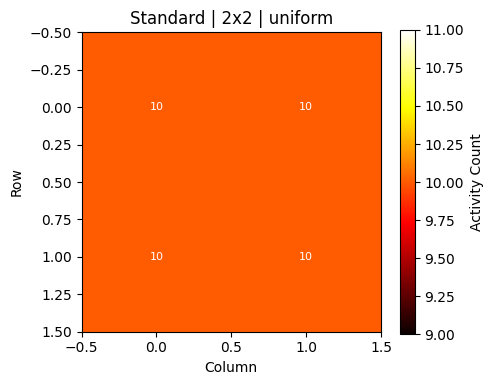

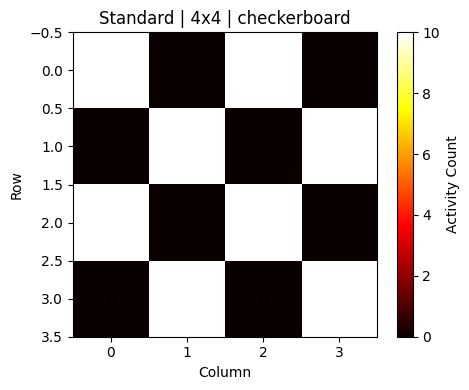

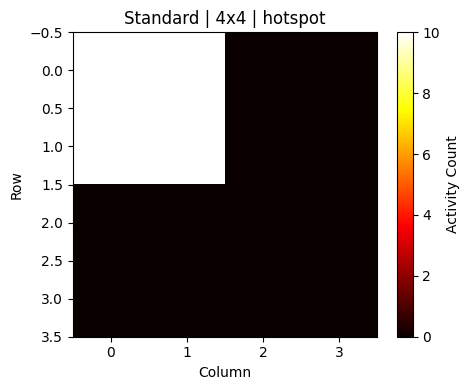

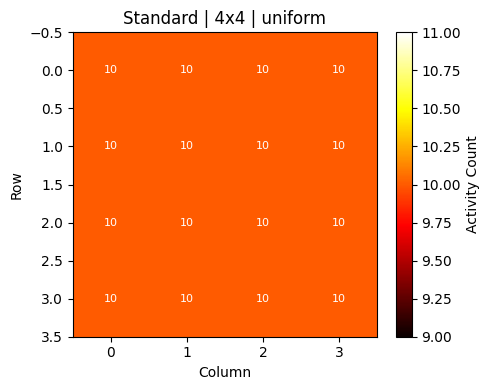

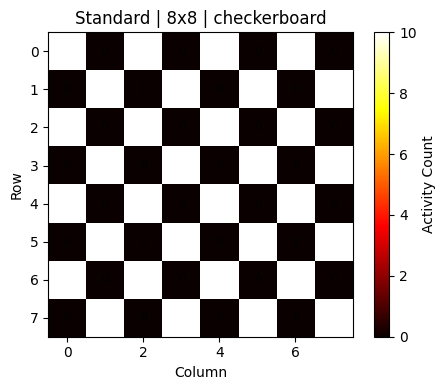

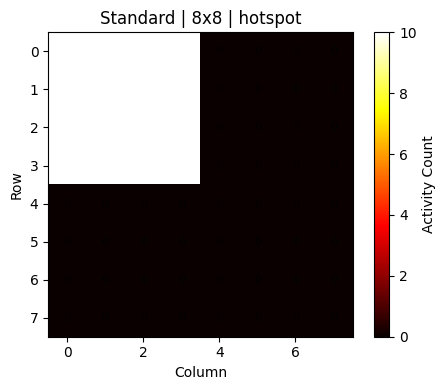

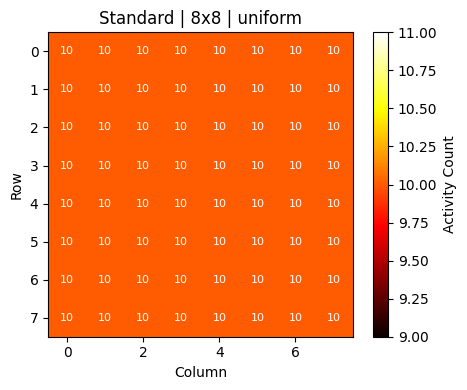

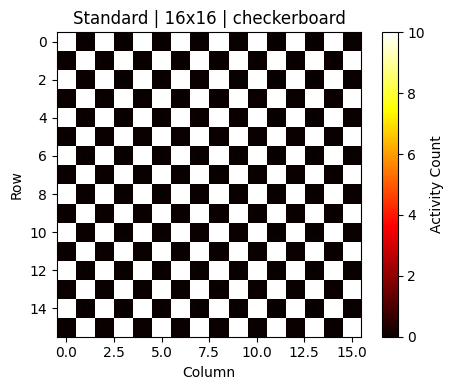

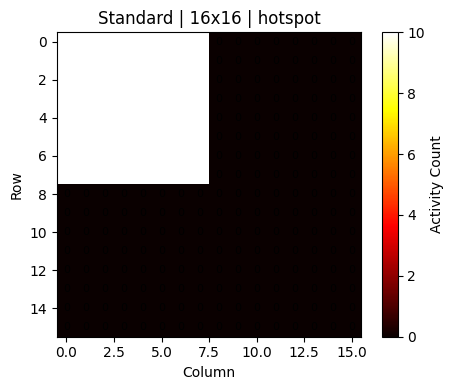

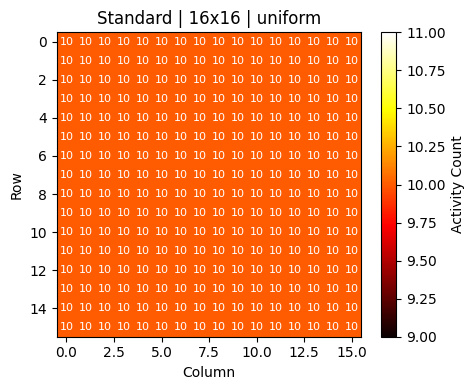

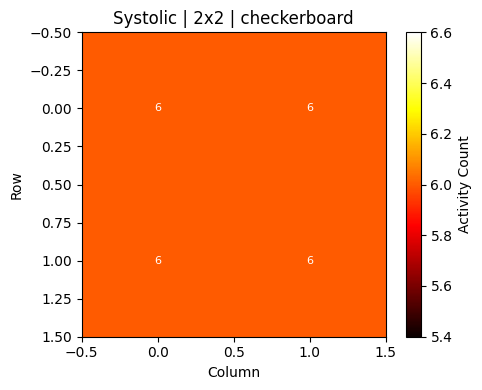

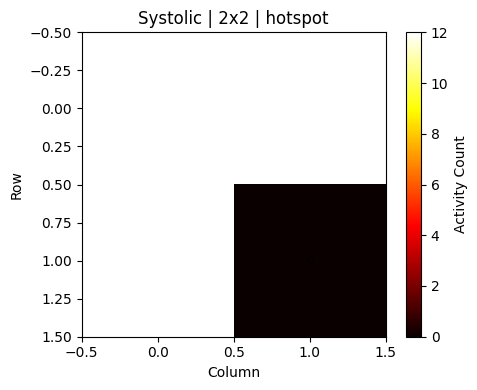

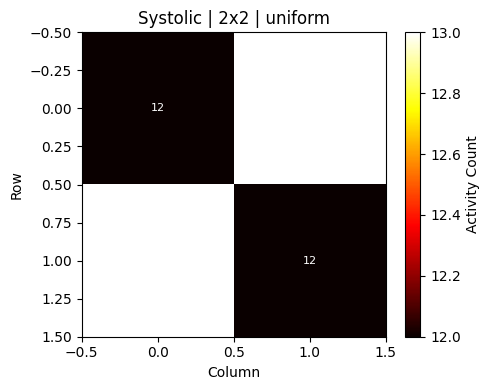

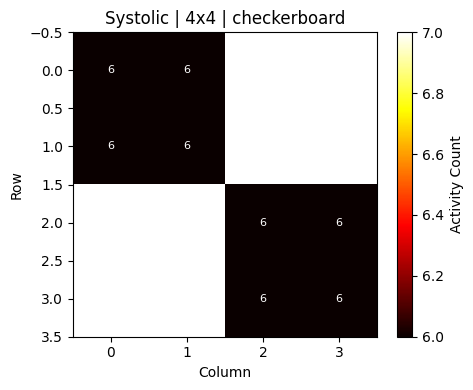

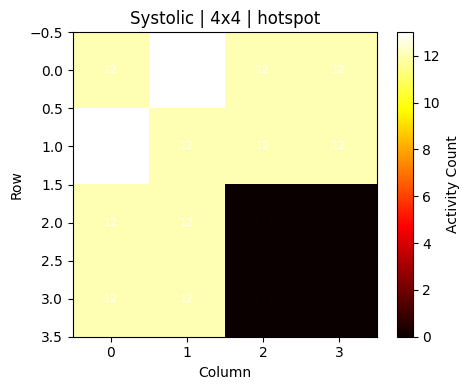

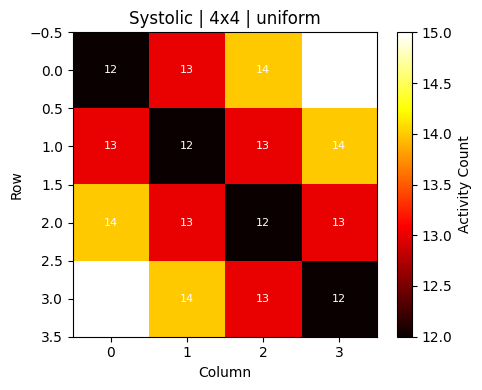

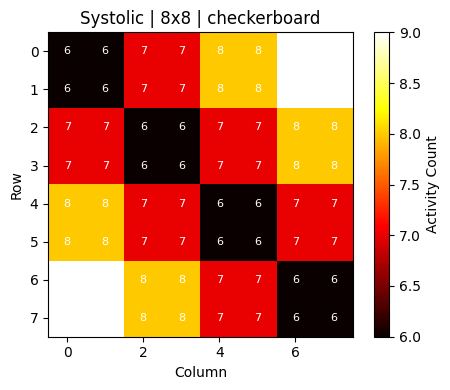

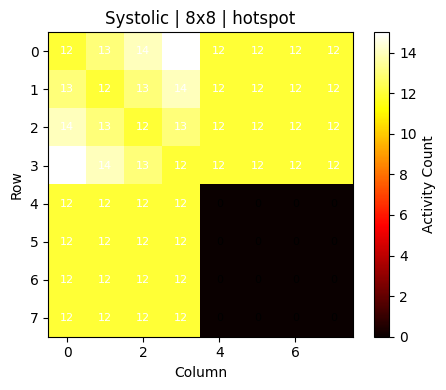

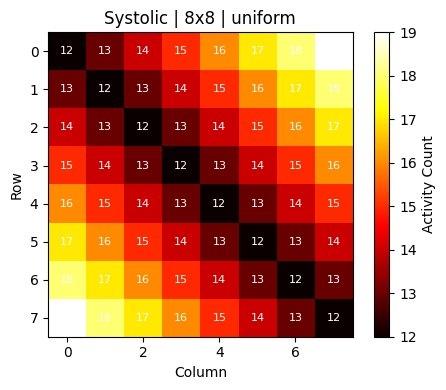

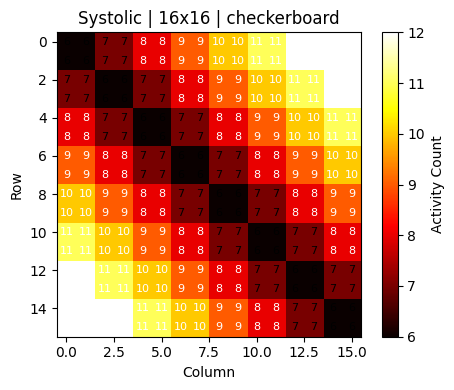

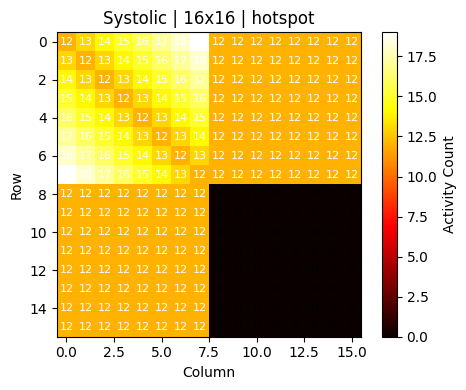

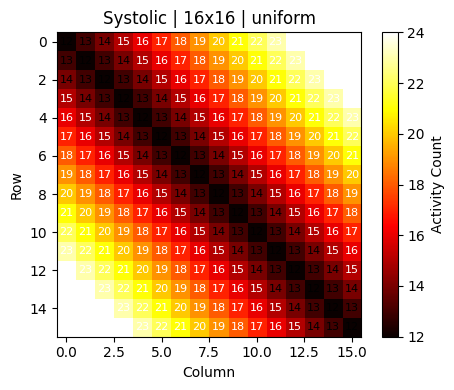

Saved all activity heatmaps, matrices, and summaries.


In [18]:
def make_case_dir(base_dir, architecture, N, workload):
    case_dir = base_dir / architecture / f"{N}x{N}" / workload
    case_dir.mkdir(parents=True, exist_ok=True)
    return case_dir


def plot_activity_heatmap(mat, title, save_path=None, annotate=True, cmap="hot"):
    plt.figure(figsize=(5, 4))
    im = plt.imshow(mat, interpolation="nearest", cmap=cmap)
    plt.colorbar(im, label="Activity Count")
    plt.title(title)
    plt.xlabel("Column")
    plt.ylabel("Row")

    if annotate:
        max_val = np.max(mat)
        threshold = 0.6 * max_val if max_val > 0 else 0

        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat[i, j]
                text_color = "white" if val >= threshold else "black"
                plt.text(j, i, f"{val}", ha="center", va="center", color=text_color, fontsize=8)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()


# Generate and save all activity heatmaps
for _, row in activity_summary_df.iterrows():
    key = (row["architecture"], row["N"], row["workload"])
    mat = all_matrices[key]

    case_dir = make_case_dir(RESULTS_DIR, row["architecture"], row["N"], row["workload"])
    heatmap_path = case_dir / "activity_heatmap.png"
    matrix_csv_path = case_dir / "activity_matrix.csv"
    summary_json_path = case_dir / "summary.json"

    # Save matrix CSV
    pd.DataFrame(mat).to_csv(matrix_csv_path, index=False)

    # Save summary JSON
    with open(summary_json_path, "w") as f:
        json.dump(
            {
                "architecture": row["architecture"],
                "workload": row["workload"],
                "N": int(row["N"]),
                "shape": row["shape"],
                "sum_activity": int(row["sum_activity"]),
                "max_activity": int(row["max_activity"]),
                "min_activity": int(row["min_activity"]),
                "mean_activity": float(row["mean_activity"]),
                "std_activity": float(row["std_activity"]),
                "nonzero_cells": int(row["nonzero_cells"]),
            },
            f,
            indent=2,
        )

    title = f"{row['architecture'].capitalize()} | {row['shape']} | {row['workload']}"
    plot_activity_heatmap(mat, title=title, save_path=heatmap_path, annotate=True)

print("Saved all activity heatmaps, matrices, and summaries.")

/tmp/ipykernel_83455/2848926545.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


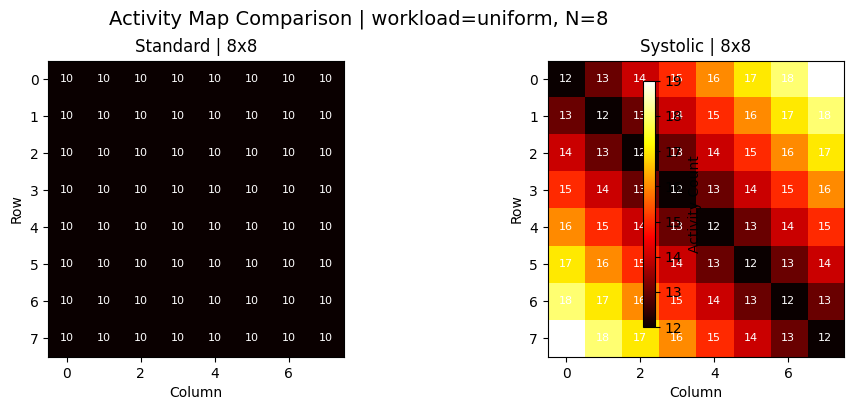

/tmp/ipykernel_83455/2848926545.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


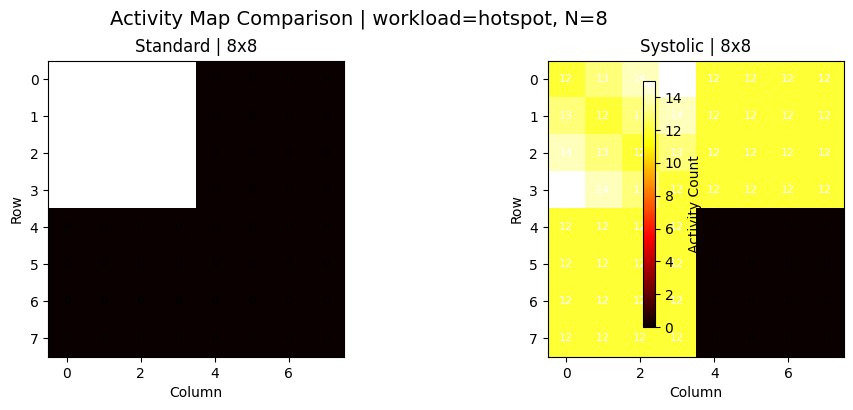

/tmp/ipykernel_83455/2848926545.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


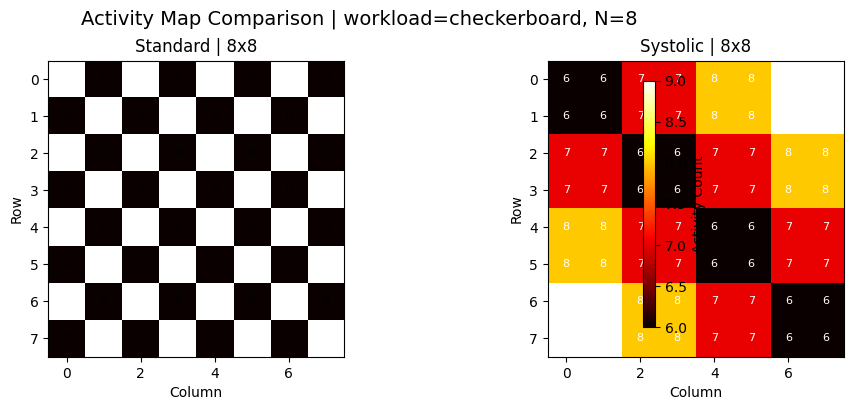

In [19]:
def plot_gallery_for_workload(workload, N):
    subset = activity_summary_df[
        (activity_summary_df["workload"] == workload) &
        (activity_summary_df["N"] == N)
    ].sort_values("architecture")

    if len(subset) == 0:
        print(f"No data for workload={workload}, N={N}")
        return

    fig, axes = plt.subplots(1, len(subset), figsize=(5 * len(subset), 4))
    if len(subset) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, subset.iterrows()):
        key = (row["architecture"], row["N"], row["workload"])
        mat = all_matrices[key]

        im = ax.imshow(mat, interpolation="nearest", cmap="hot")
        ax.set_title(f"{row['architecture'].capitalize()} | {row['shape']}")
        ax.set_xlabel("Column")
        ax.set_ylabel("Row")

        max_val = np.max(mat)
        threshold = 0.6 * max_val if max_val > 0 else 0

        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat[i, j]
                text_color = "white" if val >= threshold else "black"
                ax.text(j, i, f"{val}", ha="center", va="center", color=text_color, fontsize=8)

    fig.colorbar(im, ax=axes, shrink=0.8, label="Activity Count")
    fig.suptitle(f"Activity Map Comparison | workload={workload}, N={N}", fontsize=14)
    plt.tight_layout()
    plt.show()


# Example galleries
plot_gallery_for_workload("uniform", 8)
plot_gallery_for_workload("hotspot", 8)
plot_gallery_for_workload("checkerboard", 8)

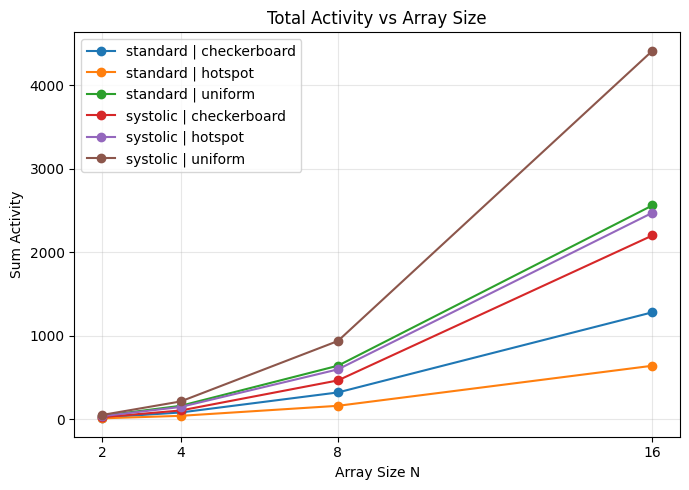

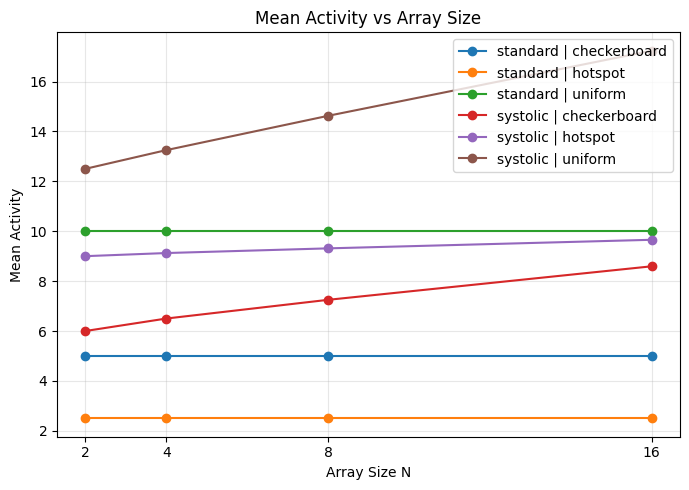

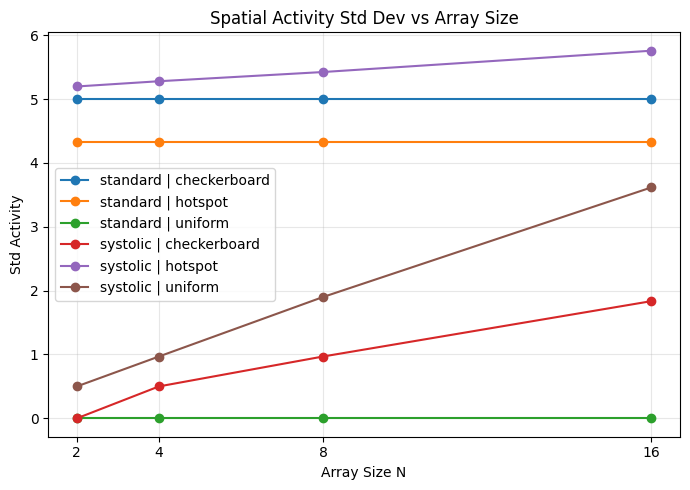

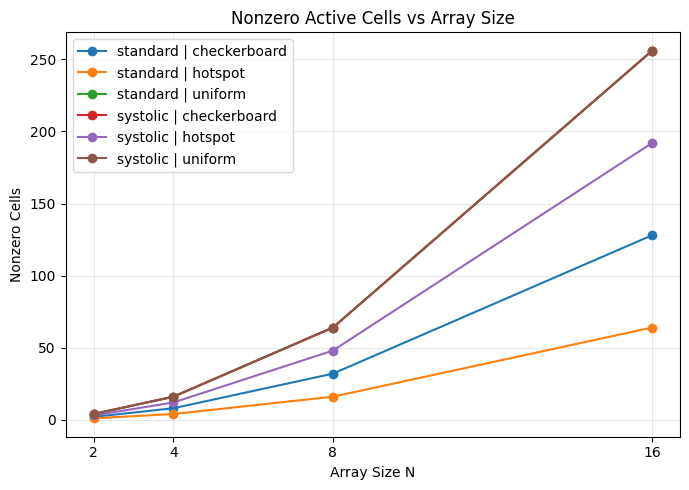

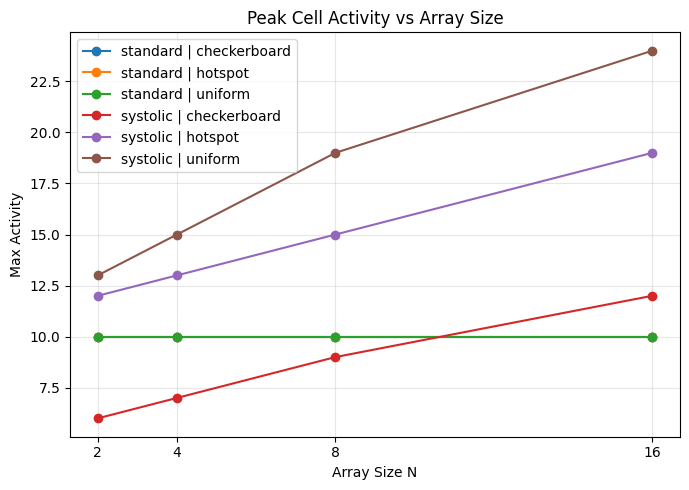

Saved comparison plots to: /home/aditya_chaudhry/thermal_aware_mac/results/activity_analysis/comparison_plots


In [20]:
plot_dir = RESULTS_DIR / "comparison_plots"
plot_dir.mkdir(parents=True, exist_ok=True)

# Make sure N is sorted numerically
plot_df = activity_summary_df.copy().sort_values(["architecture", "workload", "N"])


def save_line_plot(df, y_col, title, ylabel, filename):
    plt.figure(figsize=(7, 5))

    for arch in sorted(df["architecture"].unique()):
        for workload in sorted(df["workload"].unique()):
            sub = df[(df["architecture"] == arch) & (df["workload"] == workload)].sort_values("N")
            label = f"{arch} | {workload}"
            plt.plot(sub["N"], sub[y_col], marker="o", label=label)

    plt.title(title)
    plt.xlabel("Array Size N")
    plt.ylabel(ylabel)
    plt.xticks(sorted(df["N"].unique()))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_dir / filename, dpi=200, bbox_inches="tight")
    plt.show()


save_line_plot(
    plot_df,
    y_col="sum_activity",
    title="Total Activity vs Array Size",
    ylabel="Sum Activity",
    filename="sum_activity_vs_N.png"
)

save_line_plot(
    plot_df,
    y_col="mean_activity",
    title="Mean Activity vs Array Size",
    ylabel="Mean Activity",
    filename="mean_activity_vs_N.png"
)

save_line_plot(
    plot_df,
    y_col="std_activity",
    title="Spatial Activity Std Dev vs Array Size",
    ylabel="Std Activity",
    filename="std_activity_vs_N.png"
)

save_line_plot(
    plot_df,
    y_col="nonzero_cells",
    title="Nonzero Active Cells vs Array Size",
    ylabel="Nonzero Cells",
    filename="nonzero_cells_vs_N.png"
)

save_line_plot(
    plot_df,
    y_col="max_activity",
    title="Peak Cell Activity vs Array Size",
    ylabel="Max Activity",
    filename="max_activity_vs_N.png"
)

print("Saved comparison plots to:", plot_dir)

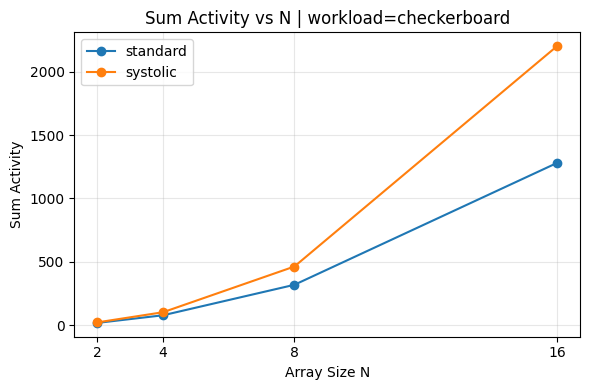

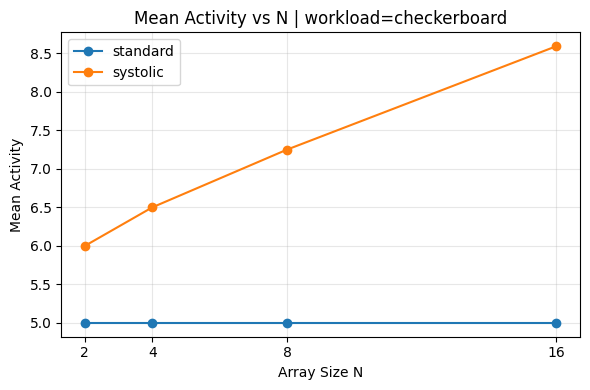

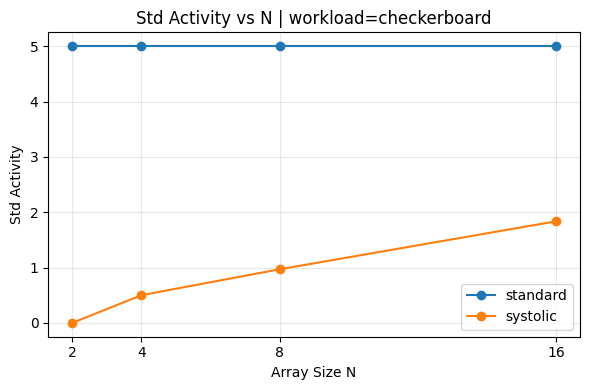

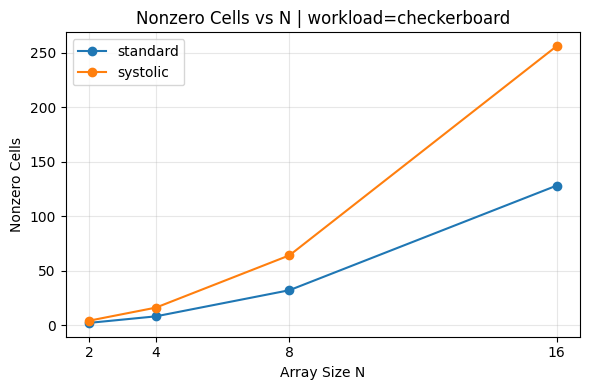

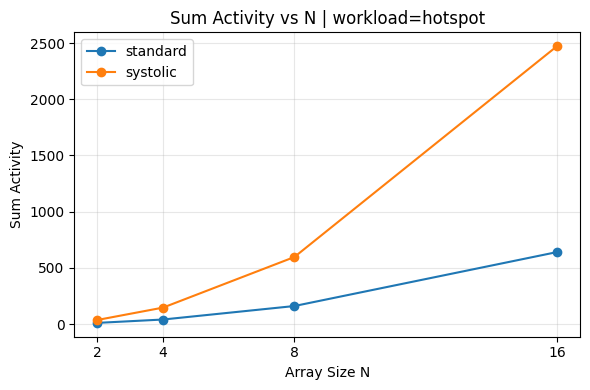

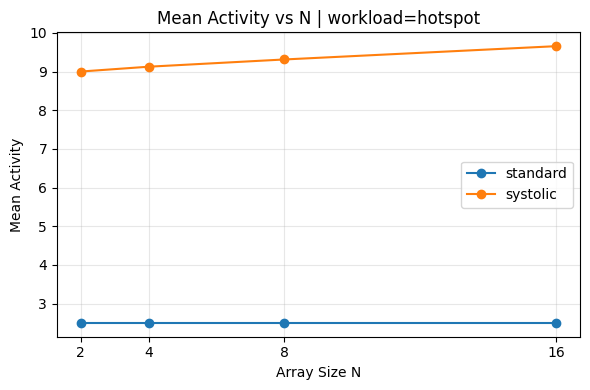

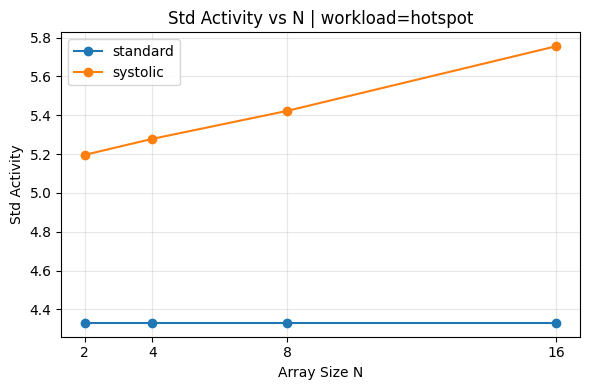

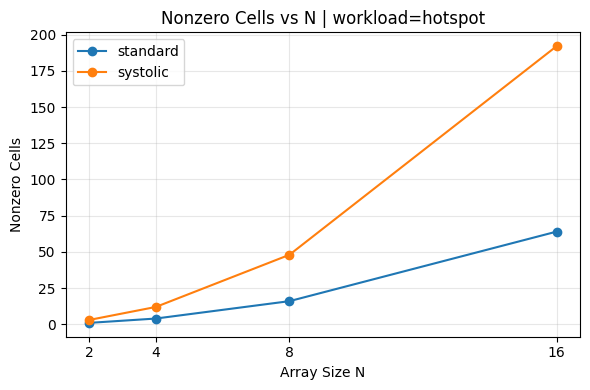

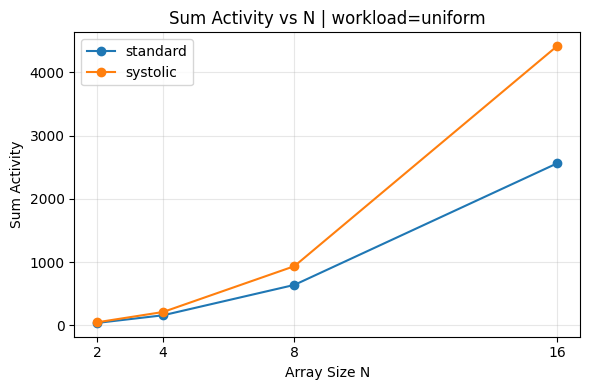

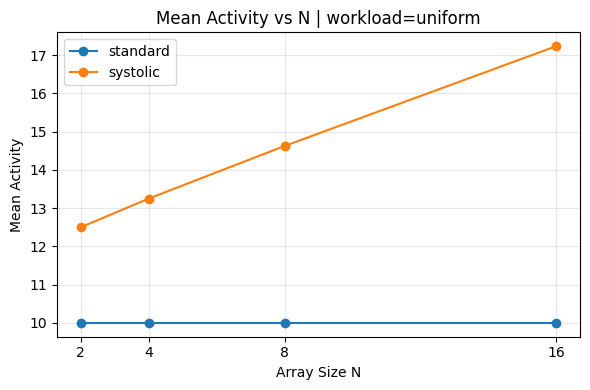

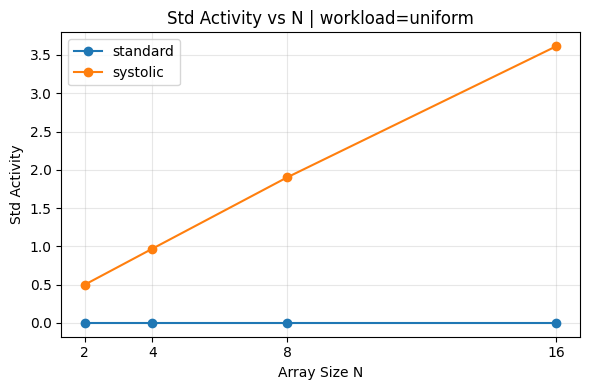

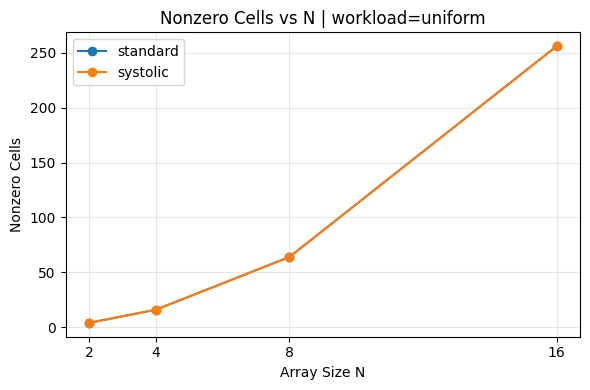

In [21]:
def architecture_comparison_plot(workload, metric, ylabel, filename_suffix):
    sub = plot_df[plot_df["workload"] == workload].sort_values(["architecture", "N"])

    plt.figure(figsize=(6, 4))

    for arch in sorted(sub["architecture"].unique()):
        arch_df = sub[sub["architecture"] == arch].sort_values("N")
        plt.plot(arch_df["N"], arch_df[metric], marker="o", label=arch)

    plt.title(f"{ylabel} vs N | workload={workload}")
    plt.xlabel("Array Size N")
    plt.ylabel(ylabel)
    plt.xticks(sorted(sub["N"].unique()))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_dir / f"{metric}_{filename_suffix}_{workload}.png", dpi=200, bbox_inches="tight")
    plt.show()


for wl in sorted(plot_df["workload"].unique()):
    architecture_comparison_plot(wl, "sum_activity", "Sum Activity", "arch_compare")
    architecture_comparison_plot(wl, "mean_activity", "Mean Activity", "arch_compare")
    architecture_comparison_plot(wl, "std_activity", "Std Activity", "arch_compare")
    architecture_comparison_plot(wl, "nonzero_cells", "Nonzero Cells", "arch_compare")

In [22]:
sum_pivot = plot_df.pivot_table(
    index=["architecture", "workload"],
    columns="N",
    values="sum_activity"
)

mean_pivot = plot_df.pivot_table(
    index=["architecture", "workload"],
    columns="N",
    values="mean_activity"
)

std_pivot = plot_df.pivot_table(
    index=["architecture", "workload"],
    columns="N",
    values="std_activity"
)

nonzero_pivot = plot_df.pivot_table(
    index=["architecture", "workload"],
    columns="N",
    values="nonzero_cells"
)

print("Sum Activity Pivot")
display(sum_pivot)

print("Mean Activity Pivot")
display(mean_pivot)

print("Std Activity Pivot")
display(std_pivot)

print("Nonzero Cells Pivot")
display(nonzero_pivot)

Sum Activity Pivot


N                            2      4      8       16
architecture workload                                
standard     checkerboard  20.0   80.0  320.0  1280.0
             hotspot       10.0   40.0  160.0   640.0
             uniform       40.0  160.0  640.0  2560.0
systolic     checkerboard  24.0  104.0  464.0  2200.0
             hotspot       36.0  146.0  596.0  2472.0
             uniform       50.0  212.0  936.0  4412.0

Mean Activity Pivot


N                            2       4        8          16
architecture workload                                      
standard     checkerboard   5.0   5.000   5.0000   5.000000
             hotspot        2.5   2.500   2.5000   2.500000
             uniform       10.0  10.000  10.0000  10.000000
systolic     checkerboard   6.0   6.500   7.2500   8.593750
             hotspot        9.0   9.125   9.3125   9.656250
             uniform       12.5  13.250  14.6250  17.234375

Std Activity Pivot


N                                2         4         8         16
architecture workload                                            
standard     checkerboard  5.000000  5.000000  5.000000  5.000000
             hotspot       4.330127  4.330127  4.330127  4.330127
             uniform       0.000000  0.000000  0.000000  0.000000
systolic     checkerboard  0.000000  0.500000  0.968246  1.834724
             hotspot       5.196152  5.278198  5.422393  5.756026
             uniform       0.500000  0.968246  1.899836  3.615255

Nonzero Cells Pivot


N                           2     4     8      16
architecture workload                            
standard     checkerboard  2.0   8.0  32.0  128.0
             hotspot       1.0   4.0  16.0   64.0
             uniform       4.0  16.0  64.0  256.0
systolic     checkerboard  4.0  16.0  64.0  256.0
             hotspot       3.0  12.0  48.0  192.0
             uniform       4.0  16.0  64.0  256.0